In [ ]:
!git clone https://github.com/aslin72/GEN---AI-course.git


Cloning into 'GEN---AI-course'...
remote: Enumerating objects: 40, done.
remote: Counting objects: 100% (40/40), done.
remote: Compressing objects: 100% (37/37), done.
remote: Total 40 (delta 2), reused 4 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (40/40), 3.59 MiB | 5.33 MiB/s, done.
Resolving deltas: 100% (2/2), done.


In [ ]:
%cd GEN---AI-course/GEN---AI-course/customer_service_chatbot_LLM


/content/GEN---AI-course/GEN---AI-course/customer_service_chatbot_LLM


In [ ]:
!find . -name "*.py"

./src/main.py
./src/langchain_helper.py


In [ ]:
!git clone https://github.com/aslin72/GEN---AI-course.git

Cloning into 'GEN---AI-course'...
remote: Enumerating objects: 40, done.
remote: Counting objects: 100% (40/40), done.
remote: Compressing objects: 100% (37/37), done.
remote: Total 40 (delta 2), reused 4 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (40/40), 3.59 MiB | 5.82 MiB/s, done.
Resolving deltas: 100% (2/2), done.


In [ ]:
with open('src/main.py', 'r') as f:
    print(f.read())

import streamlit as st
from langchain_helper import get_qa_chain, create_vector_db

st.title(" CUSTOMER SERVICE CHATBOT 🤖")
btn = st.button("Create Knowledgebase")
if btn:
    create_vector_db()

question = st.text_input("Question: ")

if question:
    chain = get_qa_chain()
    response = chain(question)

    st.header("Answer")
    st.write(response["result"])



In [ ]:
with open('src/langchain_helper.py', 'r') as f:
    print(f.read())

from langchain.vectorstores import FAISS
from langchain.llms import GooglePalm
from langchain.document_loaders.csv_loader import CSVLoader
from langchain.embeddings import HuggingFaceInstructEmbeddings
from langchain.prompts import PromptTemplate
from langchain.chains import RetrievalQA
import os

from dotenv import load_dotenv

load_dotenv()  # take environment variables from .env (especially openai api key)

# Create Google Palm LLM model
llm = GooglePalm(google_api_key=os.environ["GOOGLE_API_KEY"], temperature=0.1)
# # Initialize instructor embeddings using the Hugging Face model
instructor_embeddings = HuggingFaceInstructEmbeddings(
    model_name="hkunlp/instructor-large"
)
vectordb_file_path = "faiss_index"


def create_vector_db():
    # Load data from FAQ sheet
    loader = CSVLoader(file_path="dataset.csv", source_column="prompt")
    data = loader.load()

    # Create a FAISS instance for vector database from 'data'
    vectordb = FAISS.from_documents(documents=data, embeddin

In [ ]:
!ls


dataset  GEN---AI-course  README.md  requirements.txt  src


In [ ]:
!find . -type f

./GEN---AI-course/GEN---AI-course/NLP/NLP_bot/main.py
./GEN---AI-course/GEN---AI-course/NLP/NLP_bot/words.pkl
./GEN---AI-course/GEN---AI-course/NLP/NLP_bot/model/words.pkl
./GEN---AI-course/GEN---AI-course/NLP/NLP_bot/model/classes.pkl
./GEN---AI-course/GEN---AI-course/NLP/NLP_bot/model/chatbot_model.h5
./GEN---AI-course/GEN---AI-course/NLP/NLP_bot/Data/intents.json
./GEN---AI-course/GEN---AI-course/NLP/NLP_bot/Data/requirements.txt
./GEN---AI-course/GEN---AI-course/NLP/NLP_bot/chat_history_20240710_160748.txt
./GEN---AI-course/GEN---AI-course/NLP/NLP_bot/gui1.py
./GEN---AI-course/GEN---AI-course/NLP/NLP_bot/chat_history.txt
./GEN---AI-course/GEN---AI-course/NLP/NLP_bot/classes.pkl
./GEN---AI-course/GEN---AI-course/NLP/NLP_bot/chatbot_model.h5
./GEN---AI-course/GEN---AI-course/NLP/NLP_Word2vec.ipynb
./GEN---AI-course/GEN---AI-course/NLP/NLP (1).ipynb
./GEN---AI-course/GEN---AI-course/NLP/SMSSpamCollection.txt
./GEN---AI-course/GEN---AI-course/LLM/End-To-End-Gemini-Project-main/src/img_

In [ ]:
import pandas as pd

df = pd.read_csv(
    "dataset/dataset.csv",
    encoding="latin1"
)

print(df.head())

print("\nColumns:")
print(df.columns)

print("\nRows:")
print(len(df))

                                              prompt  \
0  I have never done programming in my life. Can ...   
1                      Why should I trust Nullclass?   
2  Is there any prerequisite for taking this boot...   
3  What datasets are used in this bootcamp? Is it...   
4  Im not sure if this bootcamp is good enough f...   

                                            response  
0  Yes, this is the perfect training for anyone w...  
1  Till now 9000 + learners have benefitted from ...  
2  Our bootcamp is specifically designed for begi...  
3  The datasets used in this bootcamp are crafted...  
4  We got you covered. Go ahead and watch our you...  

Columns:
Index(['prompt', 'response'], dtype='object')

Rows:
76


In [ ]:
import os

os.makedirs("updates", exist_ok=True)

print("updates folder created")


updates folder created


In [ ]:
import pandas as pd

new_faqs = pd.DataFrame({
    "prompt": [
        "Do you provide AI internships?",
        "What is Generative AI?"
    ],
    "response": [
        "Yes, we provide AI internships.",
        "Generative AI creates text, images, code, and other content."
    ]
})

new_faqs.to_csv(
    "updates/new_faqs.csv",
    index=False
)

print("new_faqs.csv created")

new_faqs.csv created


In [ ]:
pd.read_csv("updates/new_faqs.csv")

,prompt,response
0,Do you provide AI internships?,"Yes, we provide AI internships."
1,What is Generative AI?,"Generative AI creates text, images, code, and ..."


In [ ]:
import pandas as pd
import os

MAIN_DATASET = "dataset/dataset.csv"
UPDATE_FOLDER = "updates"

def update_dataset():

    main_df = pd.read_csv(
        MAIN_DATASET,
        encoding="latin1"
    )

    print("Original FAQs:", len(main_df))

    for file in os.listdir(UPDATE_FOLDER):

        if file.endswith(".csv"):

            path = os.path.join(
                UPDATE_FOLDER,
                file
            )

            new_df = pd.read_csv(path)

            main_df = pd.concat(
                [main_df, new_df],
                ignore_index=True
            )

    main_df.drop_duplicates(
        subset=["prompt"],
        inplace=True
    )

    print("Updated FAQs:", len(main_df))

    main_df.to_csv(
        "dataset/updated_dataset.csv",
        index=False
    )

    return main_df

In [ ]:
updated_df = update_dataset()

updated_df.tail()

Original FAQs: 76
Updated FAQs: 78


,prompt,response
73,How do I update source in power query ?,Follow the discord link : \n\n https://discord...
74,How do I enable Power Pivot before using it fo...,Follow the process in the link : \n\nhttps://d...
75,who are you,"Hi there, I am your virtual assistant develop..."
76,Do you provide AI internships?,"Yes, we provide AI internships."
77,What is Generative AI?,"Generative AI creates text, images, code, and ..."


In [ ]:
!cat requirements.txt

langchain==0.0.339
python-dotenv==1.0.0
streamlit==1.22.0
tiktoken==0.4.0
faiss-cpu==1.7.4
protobuf~=3.19.0
sentence-transformer== 2.2.2

In [ ]:
!pip list | grep langchain

langchain                                1.3.1
langchain-core                           1.4.0
langchain-protocol                       0.0.15


In [ ]:
!pip list | grep faiss


In [ ]:
!pwd

/content/GEN---AI-course/GEN---AI-course/customer_service_chatbot_LLM


In [ ]:
!ls dataset

dataset.csv  updated_dataset.csv


In [ ]:
import pandas as pd

df = pd.read_csv(
    "dataset/updated_dataset.csv"
)

print("Rows:", len(df))
print(df.tail())

Rows: 78
                                               prompt  \
73            How do I update source in power query ?   
74  How do I enable Power Pivot before using it fo...   
75                                        who are you   
76                     Do you provide AI internships?   
77                             What is Generative AI?   

                                             response  
73  Follow the discord link : \n\n https://discord...  
74  Follow the process in the link : \n\nhttps://d...  
75   Hi there, I am your virtual assistant develop...  
76                    Yes, we provide AI internships.  
77  Generative AI creates text, images, code, and ...  


In [ ]:
!pip install -q langchain-community

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 2.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [ ]:
from langchain_community.document_loaders.csv_loader import CSVLoader

print("CSVLoader imported successfully")

/tmp/ipykernel_2219/1273337447.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders.csv_loader import CSVLoader


CSVLoader imported successfully


In [ ]:
from langchain_community.document_loaders.csv_loader import CSVLoader

loader = CSVLoader(
    file_path="dataset/updated_dataset.csv",
    source_column="prompt"
)

docs = loader.load()

print("Documents Loaded:", len(docs))
print("\nFirst Document:\n")
print(docs[0])

Documents Loaded: 78

First Document:

page_content='prompt: I have never done programming in my life. Can I take this course?
response: Yes, this is the perfect training for anyone who has never done coding and wants to build a career in the AI industry or just wants to perform better in your current job or business using data.' metadata={'source': 'I have never done programming in my life. Can I take this course?', 'row': 0}


In [ ]:
!pip show langchain-community

Name: langchain-community
Version: 0.4.2
Summary: Community contributed LangChain integrations.
Home-page: https://docs.langchain.com/
Author: 
Author-email: 
License: MIT
Location: /usr/local/lib/python3.12/dist-packages
Requires: aiohttp, httpx-sse, langchain-classic, langchain-core, langsmith, numpy, pydantic-settings, pyyaml, requests, sqlalchemy, tenacity
Required-by: 


In [ ]:
from langchain_community.document_loaders.csv_loader import CSVLoader

In [ ]:
from langchain_community.document_loaders import CSVLoader

print("CSVLoader imported successfully")

CSVLoader imported successfully


In [ ]:
from langchain_community.document_loaders import CSVLoader

loader = CSVLoader(
    file_path="dataset/updated_dataset.csv",
    source_column="prompt",
    encoding="latin1"
)

docs = loader.load()

print("Documents Loaded:", len(docs))

Documents Loaded: 78


In [ ]:
!pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 31.8 MB/s eta 0:00:00


In [ ]:
!pip show sentence-transformers

Name: sentence-transformers
Version: 5.5.1
Summary: Embeddings, Retrieval, and Reranking
Home-page: https://www.SBERT.net
Author: 
Author-email: Nils Reimers <info@nils-reimers.de>, Tom Aarsen <tom.aarsen@huggingface.co>
License: Apache 2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: huggingface-hub, numpy, scikit-learn, scipy, torch, tqdm, transformers, typing_extensions
Required-by: 


In [ ]:

import faiss

print("FAISS Version:", faiss.__version__)

FAISS Version: 1.14.2


In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

print("Embedding Model Loaded")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding Model Loaded


In [ ]:
import pandas as pd

df = pd.read_csv(
    "dataset/updated_dataset.csv"
)

texts = (
    df["prompt"].astype(str)
    + " "
    + df["response"].astype(str)
).tolist()

print("Total Documents:", len(texts))

Total Documents: 78


In [ ]:
embeddings = model.encode(
    texts,
    show_progress_bar=True
)

print("Embedding Shape:", embeddings.shape)

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Embedding Shape: (78, 384)


In [ ]:
import faiss
import numpy as np-

dimension = embeddings.shape[1]

index = faiss.IndexFlatL2(dimension)

index.add(
    np.array(embeddings).astype("float32")
)

print("Vectors Stored:", index.ntotal)

Vectors Stored: 78


In [ ]:
faiss.write_index(
    index,
    "updated_faiss.index"
)

print("Vector DB Saved")

Vector DB Saved


In [ ]:
import numpy as np
import faiss

query = "Do you provide AI internships?"

query_embedding = model.encode([query])

D, I = index.search(
    np.array(query_embedding).astype("float32"),
    k=3
)

print("Nearest Matches:")
print(I)

Nearest Matches:
[[76 14 12]]


In [ ]:
for idx in I[0]:
    print("\n-------------------")
    print(df.iloc[idx]["prompt"])
    print(df.iloc[idx]["response"])


-------------------
Do you provide AI internships?
Yes, we provide AI internships.

-------------------
Do you provide any virtual internship?
Yes 

-------------------
Is this project training enough for me to get complete knowledge in GEN-AI?
Yes, this course  will certainly help because we cover the majority of the skills measured in these exams. However, please be informed that this course focuses on Job ready aspects and not on all aspects required to clear the exams. In addition to this course, you might need to visit the official learning material designed by openai / meta AI which is available for free on their website.


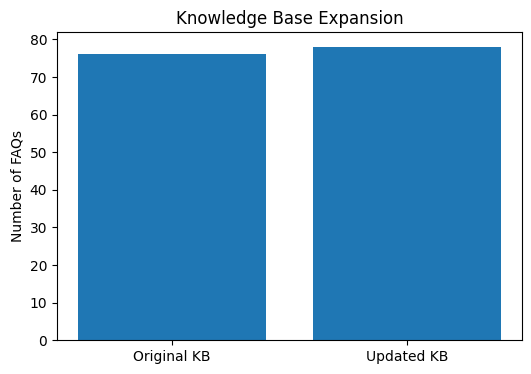

In [ ]:
import matplotlib.pyplot as plt

labels = ["Original KB", "Updated KB"]
values = [76, 78]

plt.figure(figsize=(6,4))
plt.bar(labels, values)
plt.title("Knowledge Base Expansion")
plt.ylabel("Number of FAQs")
plt.show()

**Results**

Knowledge Base increased from 76 to 78 FAQs.
New AI Internship and Generative AI questions are successfully retrieved.

In [ ]:
from google.colab import files
files.download("dataset/updated_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>